# 7_ 6Convolutional Neural Networks (LeNet)

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## LeNet

In [2]:
def init_cnn(module):  #@save
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class LeNet(d2l.Classifier):  #@save
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

In [3]:
@d2l.add_to_class(d2l.Classifier)  #@save
def layer_summary(self, X_shape):
    X = torch.randn(*X_shape)
    for layer in self.net:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

model = LeNet()
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


## Training

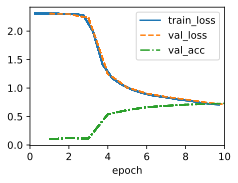

In [5]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = LeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

# Exercises

## Ex. 1.1

In [6]:
class MaxPoolLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

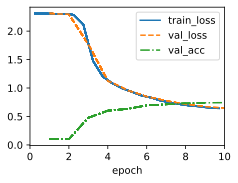

In [6]:
model = MaxPoolLeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

## Ex. 1.2

In [7]:
class ReluLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes))

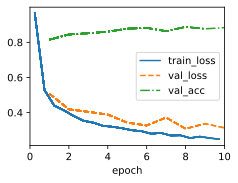

In [8]:
model = ReluLeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

## Ex.2

### 2.1 Adjusting convolution window size 

In [6]:
class LeNet2_1(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10, conv_size=5):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=conv_size, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=conv_size), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes))

#### conv_size=6

In [7]:
model = LeNet2_1(lr=0.1, num_classes=10, conv_size=6)

In [8]:
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 27, 27])
ReLU output shape:	 torch.Size([1, 6, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 6, 13, 13])
Conv2d output shape:	 torch.Size([1, 16, 8, 8])
ReLU output shape:	 torch.Size([1, 16, 8, 8])
MaxPool2d output shape:	 torch.Size([1, 16, 4, 4])
Flatten output shape:	 torch.Size([1, 256])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


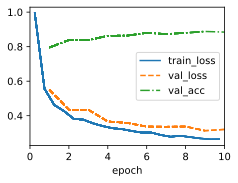

In [9]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

#### conv_size=5

In [10]:
model = LeNet2_1(lr=0.1, num_classes=10, conv_size=5)
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
ReLU output shape:	 torch.Size([1, 6, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
ReLU output shape:	 torch.Size([1, 16, 10, 10])
MaxPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


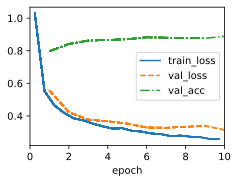

In [11]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

#### conv_size=7

In [12]:
model = LeNet2_1(lr=0.1, num_classes=10, conv_size=7)
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 26, 26])
ReLU output shape:	 torch.Size([1, 6, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 6, 13, 13])
Conv2d output shape:	 torch.Size([1, 16, 7, 7])
ReLU output shape:	 torch.Size([1, 16, 7, 7])
MaxPool2d output shape:	 torch.Size([1, 16, 3, 3])
Flatten output shape:	 torch.Size([1, 144])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


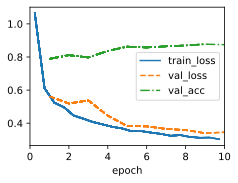

In [13]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

### 2.1 Adjusting  the number of output channels 

In [14]:
class LeNet2_2(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10, num_chan1=6, num_chan2=16):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(num_chan1, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(num_chan2, kernel_size=6), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes))

#### first - 8, second - 18

In [17]:
model = LeNet2_2(lr=0.1, num_classes=10, num_chan1=8, num_chan2=18)
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 8, 27, 27])
ReLU output shape:	 torch.Size([1, 8, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 8, 13, 13])
Conv2d output shape:	 torch.Size([1, 18, 8, 8])
ReLU output shape:	 torch.Size([1, 18, 8, 8])
MaxPool2d output shape:	 torch.Size([1, 18, 4, 4])
Flatten output shape:	 torch.Size([1, 288])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


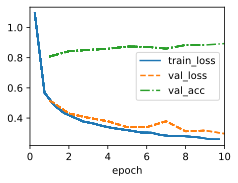

In [18]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)

#### first - 10, second - 24

In [21]:
model_2_2_2 = LeNet2_2(lr=0.1, num_classes=10, num_chan1=10, num_chan2=24)

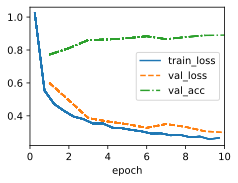

In [22]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model_2_2_2.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model_2_2_2, data)

### Adjust the number of fully connected layers.

In [25]:
class LeNet2_3(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(100), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes))

In [26]:
model_2_3 = LeNet2_3(lr=0.1, num_classes=10)
model_2_3.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 27, 27])
ReLU output shape:	 torch.Size([1, 6, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 6, 13, 13])
Conv2d output shape:	 torch.Size([1, 16, 12, 12])
ReLU output shape:	 torch.Size([1, 16, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 16, 6, 6])
Flatten output shape:	 torch.Size([1, 576])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 100])
ReLU output shape:	 torch.Size([1, 100])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


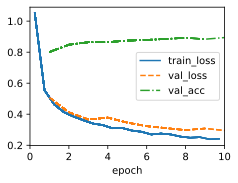

In [27]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model_2_3.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model_2_3, data)

### Adjust the learning rates and other training details

#### learning rate = 0.15

In [29]:
model5_1 = LeNet2_3(lr=0.15, num_classes=10)

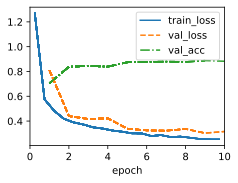

In [30]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model5_1.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model5_1, data)

#### learning rate = 0.1 | epochs = 20

In [31]:
model5_2 = LeNet2_3(lr=0.1, num_classes=10)

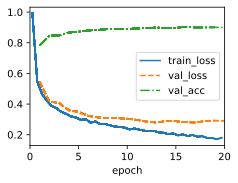

In [32]:
trainer = d2l.Trainer(max_epochs=20, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model5_2.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model5_2, data)

#### Dropout = 0.5

In [42]:
class LeNet2_5(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(100), nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(84), nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(num_classes))

In [36]:
model5_3 = LeNet2_5(lr=0.1, num_classes=10)
model5_3.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 27, 27])
ReLU output shape:	 torch.Size([1, 6, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 6, 13, 13])
Conv2d output shape:	 torch.Size([1, 16, 12, 12])
ReLU output shape:	 torch.Size([1, 16, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 16, 6, 6])
Flatten output shape:	 torch.Size([1, 576])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Dropout output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 100])
ReLU output shape:	 torch.Size([1, 100])
Dropout output shape:	 torch.Size([1, 100])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Dropout output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


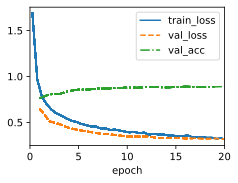

In [37]:
trainer = d2l.Trainer(max_epochs=20, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model5_3.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model5_3, data)

#### Another dropout

In [4]:
class LeNet2_52(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=6, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(100), nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(84), nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(num_classes))

In [5]:
model5_4 = LeNet2_52(lr=0.1, num_classes=10)

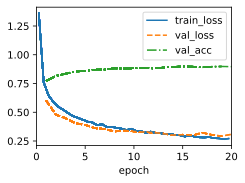

In [6]:
trainer = d2l.Trainer(max_epochs=20, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model5_4.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model5_4, data)

In [8]:
batch = next(iter(data.get_dataloader(train=False)))

X = batch[0].to(next(model5_4.parameters()).device)
Y = batch[1].to(next(model5_4.parameters()).device)

y_hat = model5_4(X)

acc = model5_4.accuracy(y_hat, Y)

print(f"Dokładne accuracy: {acc.item():.4f}")
#dsd

Dokładne accuracy: 0.8750


In [46]:
batch = next(iter(data.get_dataloader(train=False)))

X = batch[0].to(next(model5_2.parameters()).device)
Y = batch[1].to(next(model5_2.parameters()).device)

y_hat = model5_2(X)

acc = model5_2.accuracy(y_hat, Y)

print(f"Dokładne accuracy: {acc.item():.4f}")

Dokładne accuracy: 0.8516


### Ex.4

In [25]:
data = d2l.FashionMNIST(batch_size=128)
batch = next(iter(data.train_dataloader()))

In [43]:
model = LeNet2_5()
model.eval()

LeNet2_5(
  (net): Sequential(
    (0): LazyConv2d(0, 6, kernel_size=(6, 6), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): LazyConv2d(0, 16, kernel_size=(6, 6), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): LazyLinear(in_features=0, out_features=120, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.5, inplace=False)
    (10): LazyLinear(in_features=0, out_features=100, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): LazyLinear(in_features=0, out_features=84, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
    (16): LazyLinear(in_features=0, out_features=10, bias=True)
  )
)

In [44]:
act1 = model.net[0:2](batch[0]).detach().cpu()

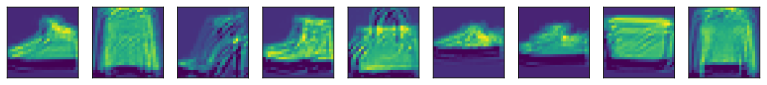

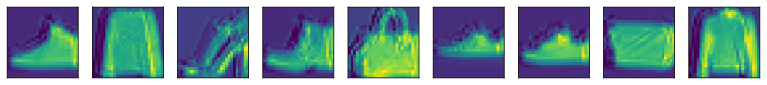

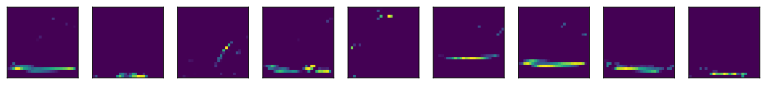

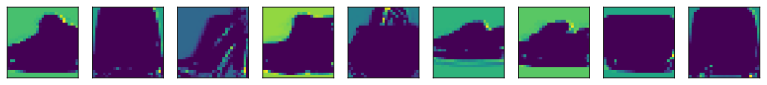

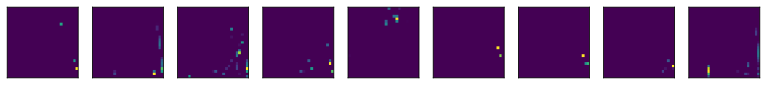

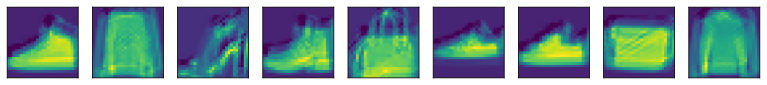

In [45]:
for i in range(6):
    layer = act1[0:9, i, :, :]
    d2l.show_images(layer.reshape(9, layer.shape[1], layer.shape[2]), 1, 9)

In [36]:
act2 = model.net[0:5](batch[0]).detach().cpu()

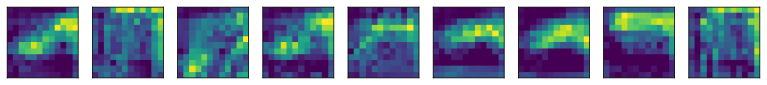

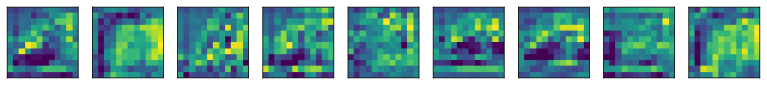

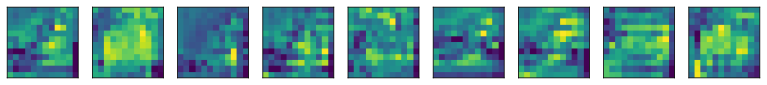

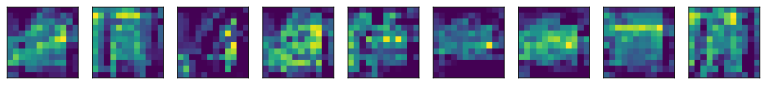

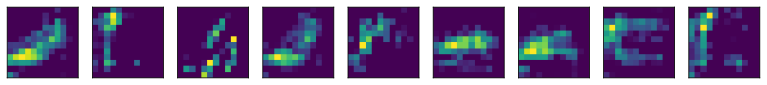

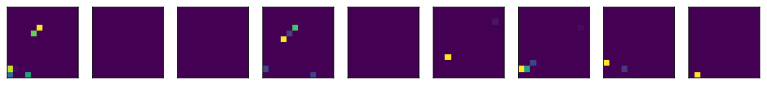

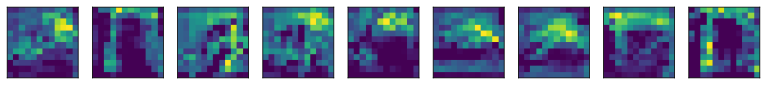

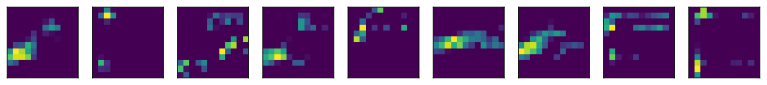

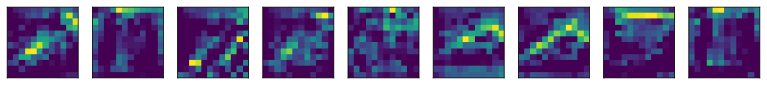

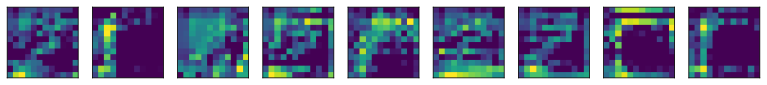

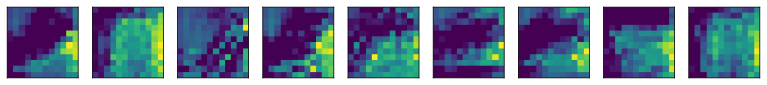

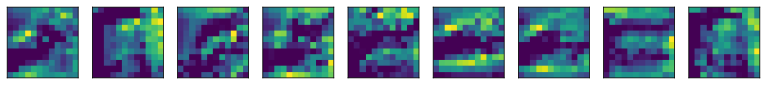

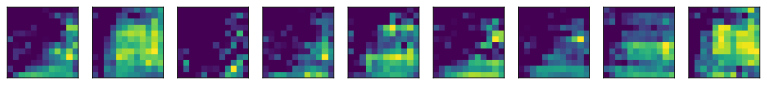

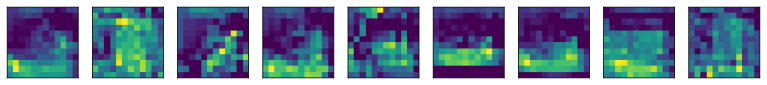

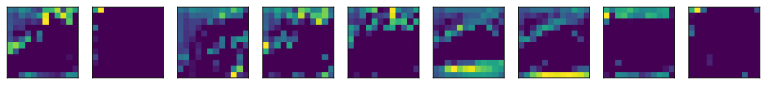

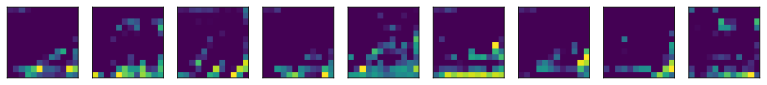

In [46]:
for i in range(16):
    layer = act2[0:9, i, :, :]
    d2l.show_images(layer.reshape(9, layer.shape[1], layer.shape[2]), 1, 9)

In [47]:
act3 = model.net[0:6](batch[0]).detach().cpu()

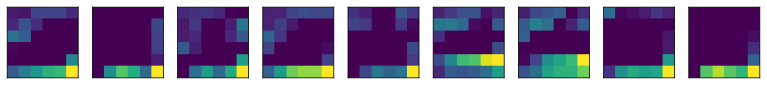

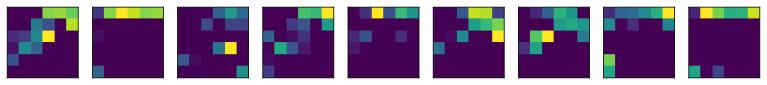

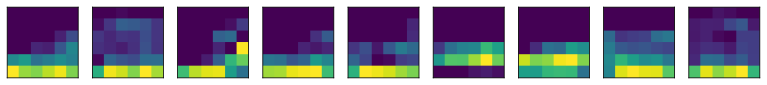

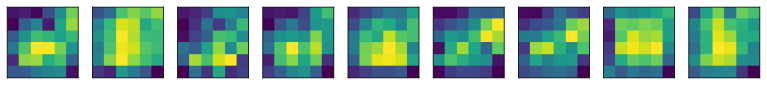

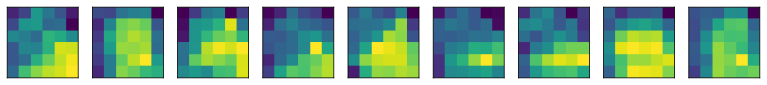

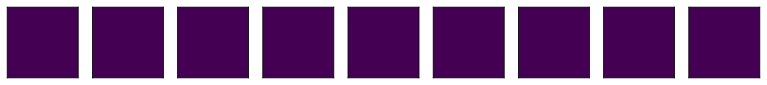

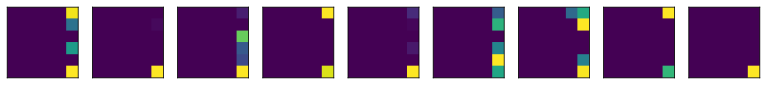

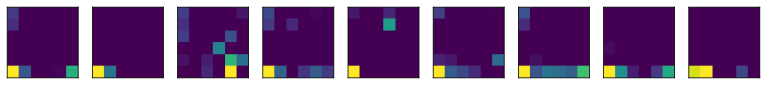

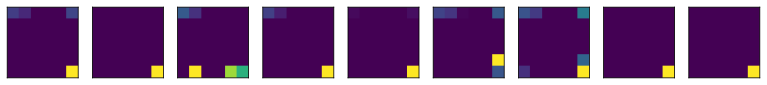

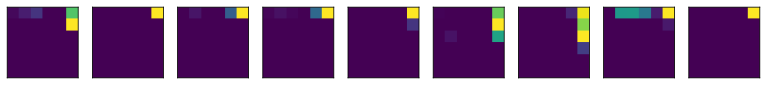

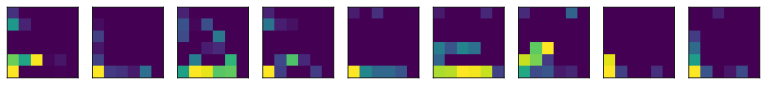

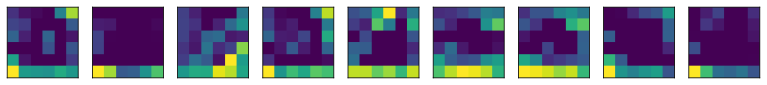

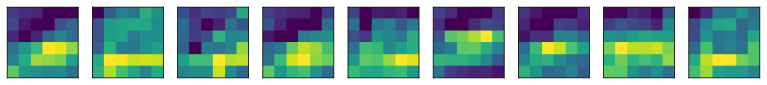

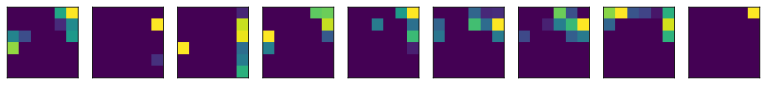

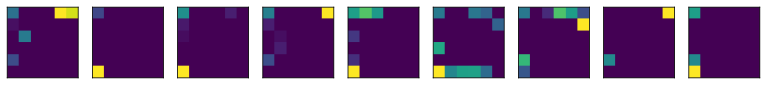

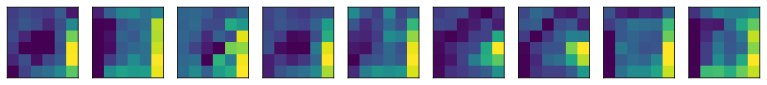

In [54]:
for i in range(16):
    layer = act3[0:9, i, :, :]
    d2l.show_images(layer.reshape(9, layer.shape[1], layer.shape[2]), 1, 9)

### Ex.5

In [55]:
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor

In [57]:
training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


In [60]:
len(training_data)

60000

In [61]:
def data_loader(data, is_train, batch_size):
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=is_train, num_workers=1)

In [62]:
X_1, y_1 = next(iter(data_loader(training_data, True, 64))) 

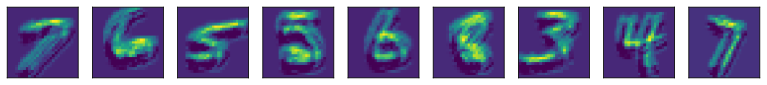

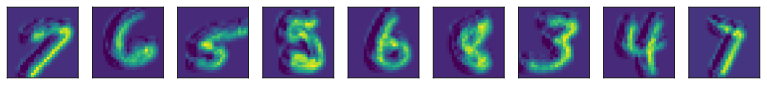

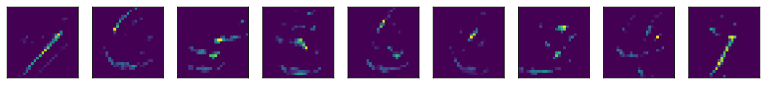

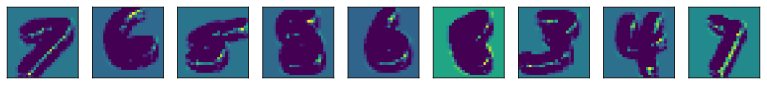

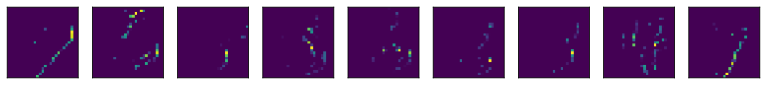

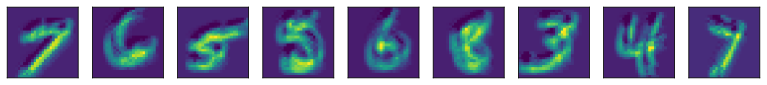

In [66]:
act1_mnist = model.net[0:2](X_1).detach().cpu()
for i in range(6):
    layer = act1_mnist[0:9, i, :, :]
    d2l.show_images(layer.reshape(9, layer.shape[1], layer.shape[2]), 1, 9)

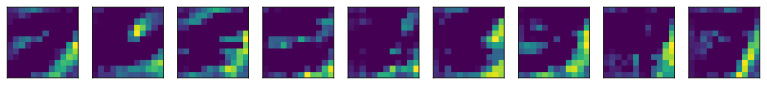

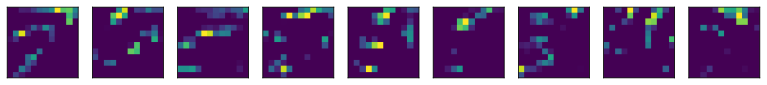

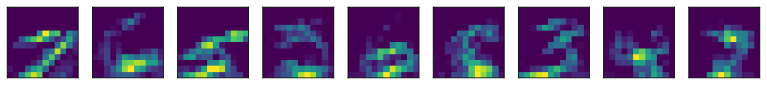

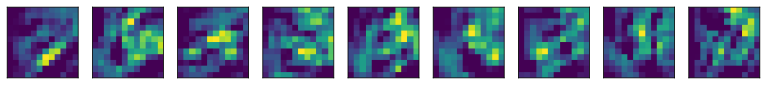

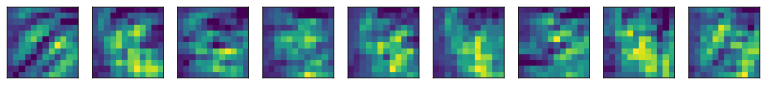

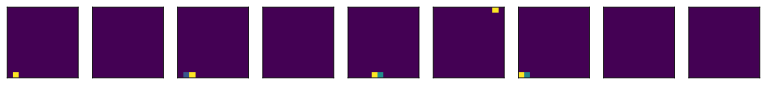

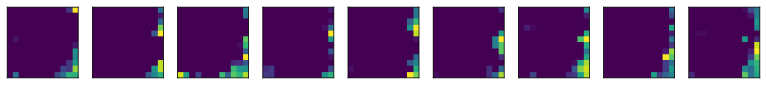

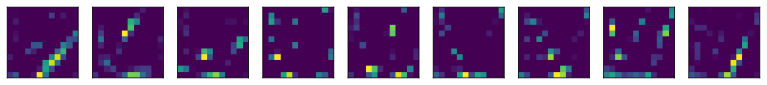

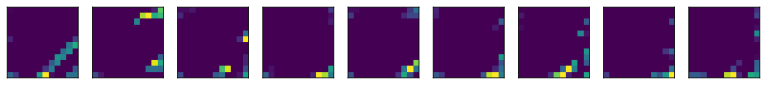

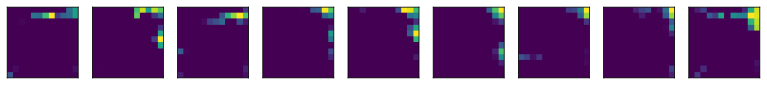

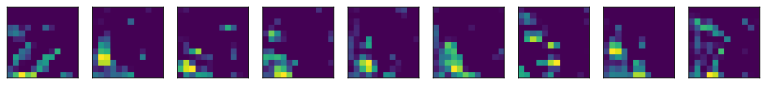

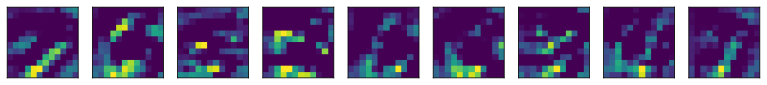

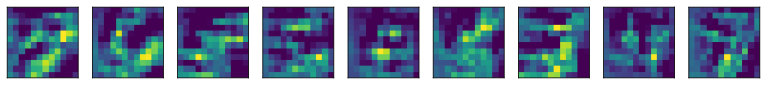

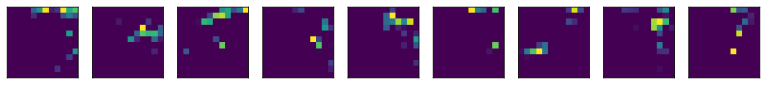

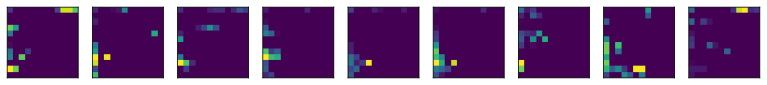

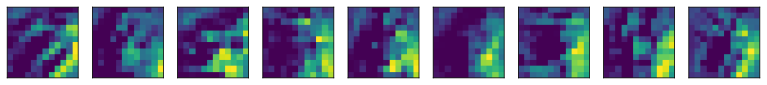

In [68]:
act2_mnist = model.net[0:5](X_1).detach().cpu()
for i in range(16):
    layer = act2_mnist[0:9, i, :, :]
    d2l.show_images(layer.reshape(9, layer.shape[1], layer.shape[2]), 1, 9)